# Section 3 – Unsupervised Learning: Topic Modeling

In this section, two topic modeling approaches are explored:

- **Latent Dirichlet Allocation (LDA)**
- **Non-negative Matrix Factorization (NMF)**

The objective is to uncover the main topics present in the drug review corpus, visualize the discovered themes, and compare the results produced by the two algorithms.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.decomposition import NMF

In [2]:
from scipy import sparse
import joblib

tfidf_matrix = sparse.load_npz("tfidf_matrix.npz")
tfidf = joblib.load("tfidf_vectorizer.joblib")

## Loading the Datasets

The lemmatized review dataset is used throughout this notebook. LDA requires a document-term matrix based on word counts, while NMF will reuse the TF-IDF representation generated in the previous section.

### Sampling Strategy

The complete dataset contains 319,934 reviews. Since topic modeling algorithms such as LDA are computationally intensive on very large corpora, a representative random sample of **50,000 reviews** was selected for this analysis.


In [7]:
df_lem = pd.read_parquet("df_lem_final.parquet")

sample_df = (
    df_lem
    .dropna(subset=["Reviews"])
    .sample(n=50000, random_state=42)
)

reviews = sample_df["Reviews"].astype(str)

print("Original dataset:", len(df_lem))
print("Sample size:", len(reviews))

Original dataset: 319934
Sample size: 50000


In [4]:
tfidf_matrix = sparse.load_npz("tfidf_matrix.npz")
tfidf = joblib.load("tfidf_vectorizer.joblib")

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (319934, 5000)


# 3.2. Latent Dirichlet Allocation (LDA)

LDA is trained using a Bag-of-Words representation produced with CountVectorizer, as the algorithm models word occurrence frequencies rather than TF-IDF weights.

In [16]:
#adding custom stop-words cause the topics we got were
#too generic

custom_stop_words = [
    "take", "use", "get", "day", "week", "month", "year",
    "work", "feel", "start", "make", "go", "time",
    "not", "no"
]
count_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    stop_words=custom_stop_words
)

dtm = count_vectorizer.fit_transform(reviews)

print("Document-Term Matrix shape:", dtm.shape)

Document-Term Matrix shape: (50000, 5000)


In [20]:
n_topics = 8

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)

lda.fit(dtm)

LatentDirichletAllocation(n_components=8, random_state=42)

### Top Keywords per Topic


In [21]:
feature_names = count_vectorizer.get_feature_names_out()

n_top_words = 10

topics = []

for topic_idx, topic in enumerate(lda.components_):

    top_words = [
        feature_names[i]
        for i in topic.argsort()[:-n_top_words - 1:-1]
    ]

    topics.append({
        "Topic": f"Topic {topic_idx + 1}",
        "Top Words": ", ".join(top_words)
    })

topics_df = pd.DataFrame(topics)

topics_df

,Topic,Top Words
0,Topic 1,"sleep, night, help, hour, well, wake, morning,..."
1,Topic 2,"drug, medication, life, doctor, would, help, k..."
2,Topic 3,"side, effect, medication, depression, drug, he..."
3,Topic 4,"weight, gain, pill, period, lose, ive, first, ..."
4,Topic 5,"pain, back, help, medication, relief, severe, ..."
5,Topic 6,"blood, drug, pressure, side, doctor, effect, h..."
6,Topic 7,"stomach, medication, severe, bad, stop, rash, ..."
7,Topic 8,"like, side, bad, felt, effect, dont, drug, it,..."


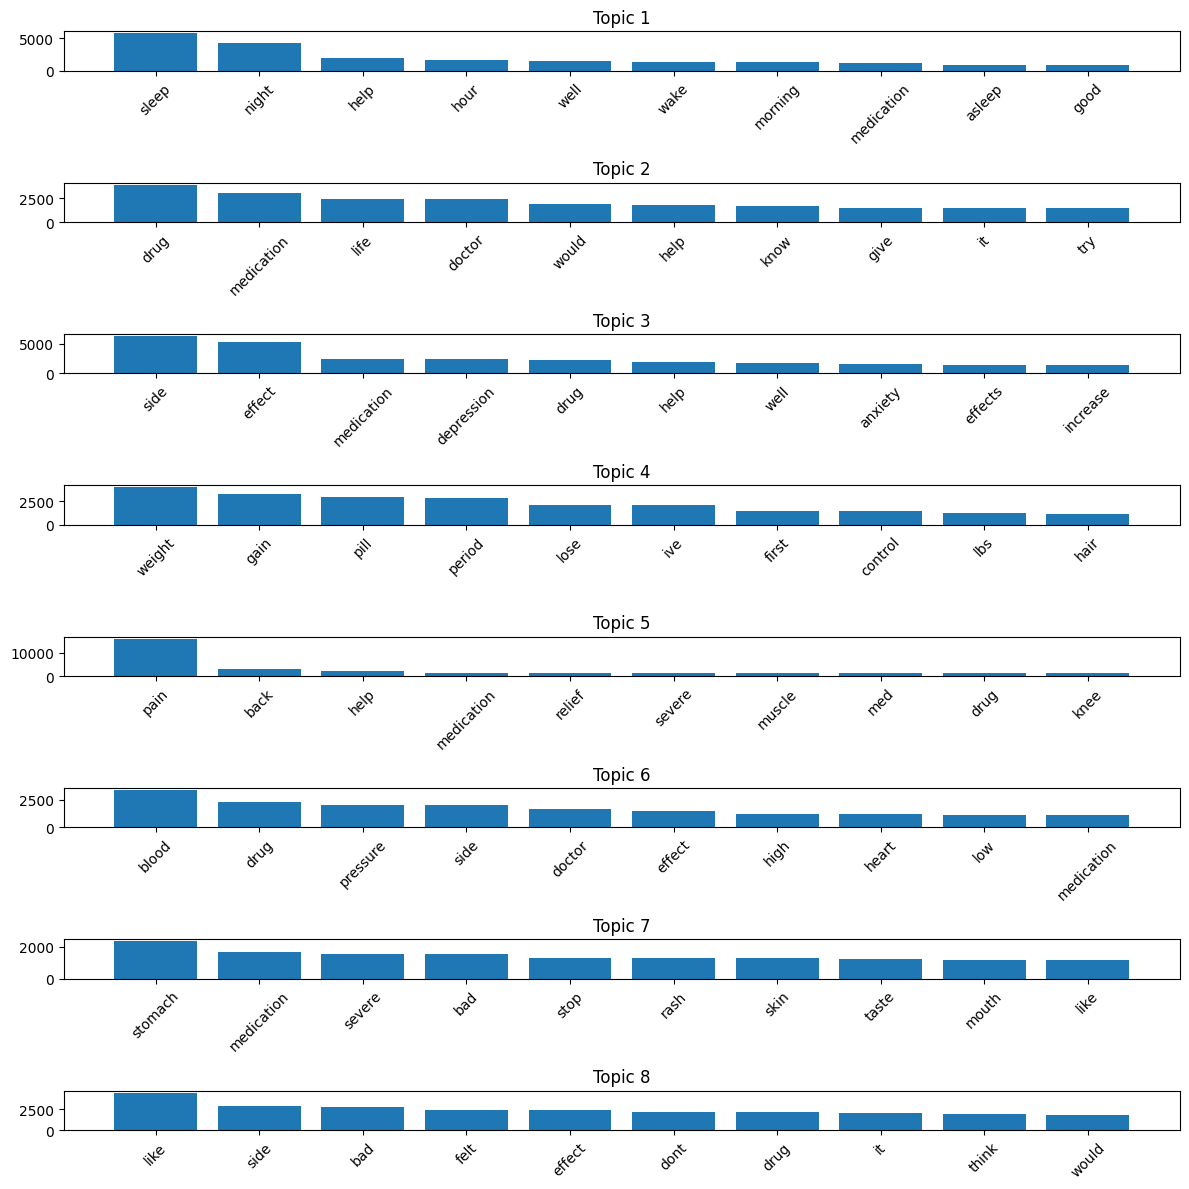

In [22]:
fig, axes = plt.subplots(n_topics, 1, figsize=(12, 12))

for idx, topic in enumerate(lda.components_):

    top_indices = topic.argsort()[-10:][::-1]

    words = [feature_names[i] for i in top_indices]
    weights = topic[top_indices]

    axes[idx].bar(words, weights)
    axes[idx].set_title(f"Topic {idx + 1}")
    axes[idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 3.3. Non-negative Matrix Factorization (NMF)


In this section, NMF is applied to the TF-IDF representation of the 50,000 sampled reviews to identify the main topics discussed in the dataset. The results will later be compared with those obtained from the LDA model to evaluate the similarities and differences between the two topic modeling approaches.

### Creating the TF-IDF Matrix

Since NMF performs best on TF-IDF features, the sampled reviews are transformed into a TF-IDF document-term matrix using the same preprocessing settings applied throughout this project.

In [23]:
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    stop_words=custom_stop_words
)

tfidf_matrix = tfidf.fit_transform(reviews)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (50000, 5000)


In [26]:
n_topics = 8

nmf = NMF(
    n_components=n_topics,
    random_state=42,
    init="nndsvda",
    max_iter=300
)

W = nmf.fit_transform(tfidf_matrix)
H = nmf.components_

In [28]:
feature_names = tfidf.get_feature_names_out()

n_top_words = 10
nmf_topics = []

for topic_idx, topic in enumerate(H):
    top_words = [
        feature_names[i]
        for i in topic.argsort()[:-n_top_words - 1:-1]
    ]

    nmf_topics.append({
        "Topic": f"Topic {topic_idx + 1}",
        "Top Words": ", ".join(top_words)
    })

nmf_topics_df = pd.DataFrame(nmf_topics)

nmf_topics_df

,Topic,Top Words
0,Topic 1,"like, pill, it, first, one, dont, would, good,..."
1,Topic 2,"pain, back, severe, relief, joint, muscle, leg..."
2,Topic 3,"side, effect, effects, bad, experience, many, ..."
3,Topic 4,"help, sleep, night, anxiety, wake, asleep, rea..."
4,Topic 5,"medication, cause, me, well, problem, severe, ..."
5,Topic 6,"drug, cause, me, problem, stop, life, doctor, ..."
6,Topic 7,"weight, gain, lose, lbs, loss, pound, mood, ea..."
7,Topic 8,"blood, pressure, high, low, sugar, lower, coug..."


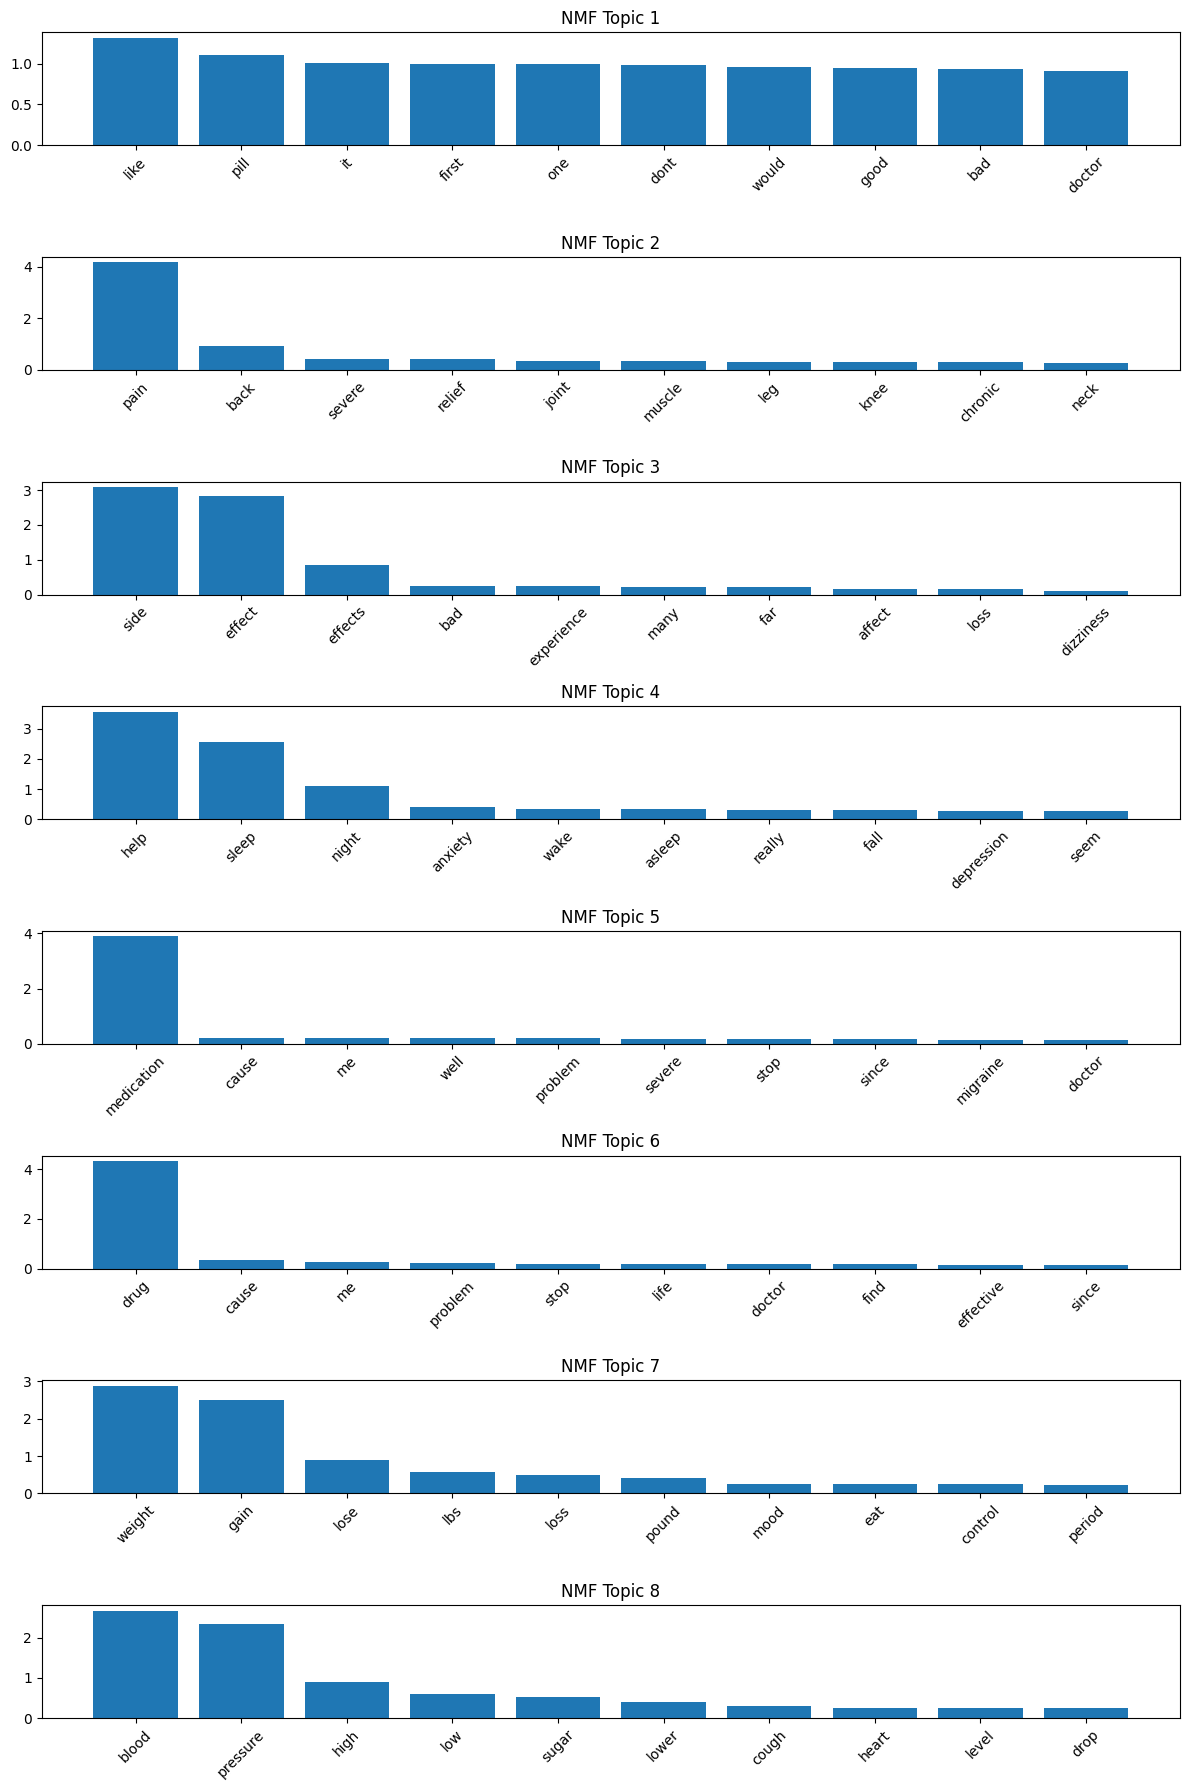

In [29]:
fig, axes = plt.subplots(n_topics, 1, figsize=(12, 18))

for idx, topic in enumerate(H):
    top_indices = topic.argsort()[-10:][::-1]

    words = [feature_names[i] for i in top_indices]
    weights = topic[top_indices]

    axes[idx].bar(words, weights)
    axes[idx].set_title(f"NMF Topic {idx + 1}")
    axes[idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Interpretation of the NMF Topics

The NMF model identified several coherent themes within the drug review corpus. Compared to the LDA results, the topics appear more focused and contain fewer overlapping medical concepts.

The identified topics can be interpreted as follows:

| Topic | Suggested Label | Description |
|:------|:----------------|:------------|
| Topic 1 | General Patient Experience | Reviews describing overall treatment experiences, opinions about medication, and interactions with doctors. |
| Topic 2 | Pain Management | Reviews related to chronic pain, back pain, muscle pain, joint pain, and pain relief. |
| Topic 3 | Medication Side Effects | Reviews discussing adverse drug reactions, side effects, dizziness, and negative experiences with medication. |
| Topic 4 | Sleep and Mental Health | Reviews focused on sleep disorders, anxiety, depression, and nighttime symptoms. |
| Topic 5 | Medication Usage | Reviews describing medication use, treatment progression, and health-related concerns. |
| Topic 6 | Drug Effectiveness | Reviews discussing the effectiveness of medications and treatment outcomes. |
| Topic 7 | Weight Changes | Reviews related to weight gain or loss, appetite, and lifestyle changes. |
| Topic 8 | Blood Pressure | Reviews discussing blood pressure, hypertension, heart-related conditions, and cardiovascular health. |

Overall, the NMF model produced well-defined and interpretable topics that capture the main health conditions, treatment outcomes, and patient experiences discussed throughout the review corpus.

## 3.4. Comparison of LDA and NMF

Both LDA and NMF were applied to the same sample of 50,000 drug reviews to identify the main topics discussed within the corpus. While both approaches successfully discovered meaningful themes, noticeable differences were observed in the quality and interpretability of the extracted topics.

| Aspect                   | LDA          | NMF          |
| ------------------------ | ------------ | ------------ |
| Topic coherence          | Good         | Higher       |
| Topic interpretability   | Moderate     | Higher       |
| Topic overlap            | Some overlap | Less overlap |
| Computational efficiency | Slower       | Faster       |


Overall, both models identified medically meaningful themes from the review corpus. However, the NMF model produced more coherent and focused topics with fewer overlapping keywords, making the results easier to interpret. For this dataset, the TF-IDF representation combined with NMF provided the clearest separation between the different medical themes discussed in the reviews.

## 3.5. Conclusion

Both models successfully identified common themes such as pain management, medication side effects, sleep disorders, cardiovascular conditions, and weight-related treatments without requiring labeled data. Although LDA produced meaningful topic clusters, some overlap between topics remained due to the probabilistic nature of the model.

The NMF model generated more focused and interpretable topics when trained on the TF-IDF representation of the reviews. This suggests that, for this dataset, NMF provided a clearer representation of the underlying themes and produced the most interpretable topics for this dataset.